In [2]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("ML environment ready!")

ML environment ready!


In [3]:
data_path = "../data/CICIDS2017/ml_ready/cicids2017_binary_ml_ready.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

Dataset shape: (288277, 79)
Number of columns: 79


In [4]:
print(df["Binary_Label"].value_counts())

print("\nLabel meaning:")
print("0 = BENIGN")
print("1 = ATTACK")

Binary_Label
0    200000
1     88277
Name: count, dtype: int64

Label meaning:
0 = BENIGN
1 = ATTACK


In [5]:
X = df.drop(columns=["Binary_Label"])
y = df["Binary_Label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (288277, 78)
Target shape: (288277,)


In [6]:
non_numeric = X.select_dtypes(
    exclude=np.number
).columns

print("Non-numeric features:")
print(non_numeric.tolist())

Non-numeric features:
[]


In [7]:
X = X.replace([np.inf, -np.inf], np.nan)

print("Missing values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X).sum().sum())

Missing values: 0
Infinite values: 0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 230621
Testing samples: 57656


In [9]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
Binary_Label
0    160000
1     70621
Name: count, dtype: int64

Testing labels:
Binary_Label
0    40000
1    17656
Name: count, dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")
model.fit(X_train, y_train)

print("Training completed!")

Training Random Forest...
Training completed!


In [13]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 57656


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9978
Precision: 0.9968
Recall   : 0.9960
F1-score : 0.9964


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "ATTACK"]
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     40000
      ATTACK       1.00      1.00      1.00     17656

    accuracy                           1.00     57656
   macro avg       1.00      1.00      1.00     57656
weighted avg       1.00      1.00      1.00     57656



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39944    56]
 [   71 17585]]


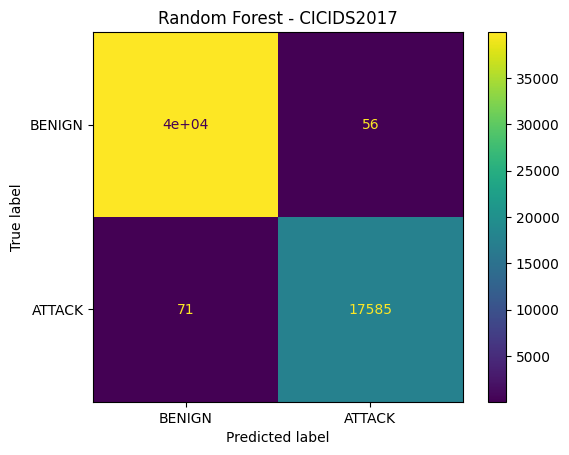

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()

plt.title("Random Forest - CICIDS2017")
plt.show()

In [18]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("Top 20 important features:")
print(feature_importance.head(20))

Top 20 important features:
Destination Port               0.060657
Max Packet Length              0.054986
Init_Win_bytes_forward         0.045853
Min Packet Length              0.045756
Bwd Packet Length Min          0.042984
Packet Length Variance         0.037469
Bwd Packet Length Std          0.036536
Avg Bwd Segment Size           0.033323
Packet Length Std              0.032143
Bwd Packet Length Max          0.031974
Fwd Packet Length Mean         0.031487
Bwd Packet Length Mean         0.030628
Avg Fwd Segment Size           0.029230
Average Packet Size            0.028545
Init_Win_bytes_backward        0.028333
Subflow Fwd Bytes              0.027817
Fwd Packet Length Min          0.026201
Fwd Header Length.1            0.018983
Packet Length Mean             0.018942
Total Length of Fwd Packets    0.018499
dtype: float64


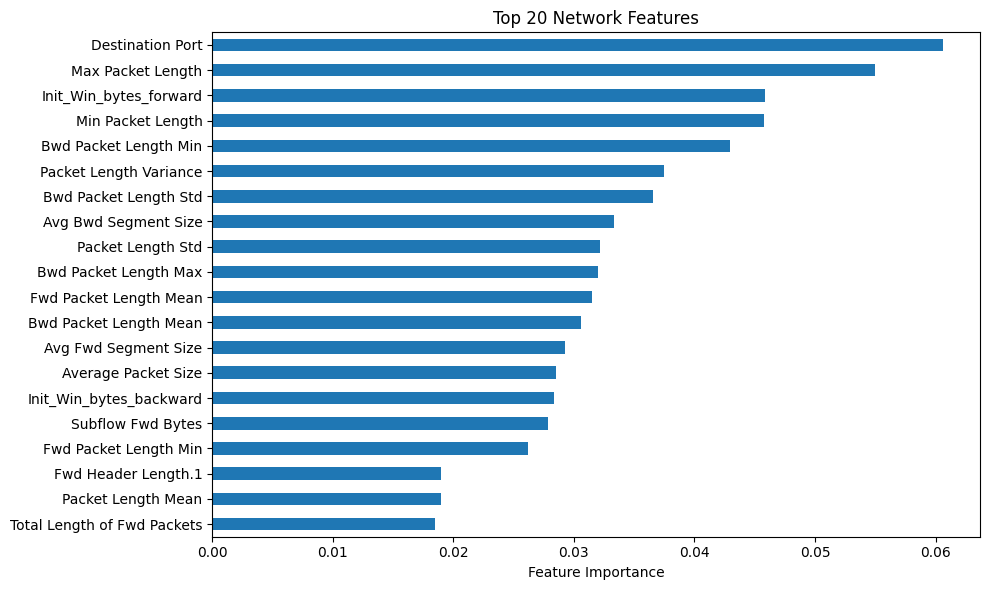

In [19]:
plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Network Features")
plt.xlabel("Feature Importance")
plt.tight_layout()

plt.show()

In [20]:
import os
import joblib

# Create model directory if it does not exist
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Save the trained Random Forest model
model_path = os.path.join(model_dir, "random_forest_baseline.joblib")

joblib.dump(model, model_path)

print("Model saved successfully!")
print("Model path:", model_path)

Model saved successfully!
Model path: ../models\random_forest_baseline.joblib
